<a href="https://colab.research.google.com/github/myra573/MeeraS/blob/main/hranalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Raw GitHub URL
url = "https://raw.githubusercontent.com/MasteriNeuron/datasets/e0da5fc18ebf4e3dc90950b932d6bded61e0ee49/hr_analytics.csv"

# Load the dataset
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
print(df.columns)
print(df['left'].value_counts())

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')
left
0    11428
1     3571
Name: count, dtype: int64


In [5]:
# Average attrition by Job Satisfaction
job_sat = df.groupby('satisfaction_level')['left'].value_counts(normalize=True).unstack()*100

print(job_sat)

left                         0           1
satisfaction_level                        
0.09                       NaN  100.000000
0.10                       NaN  100.000000
0.11                       NaN  100.000000
0.12                 86.666667   13.333333
0.13                 94.444444    5.555556
...                        ...         ...
0.96                100.000000         NaN
0.97                100.000000         NaN
0.98                100.000000         NaN
0.99                100.000000         NaN
1.00                100.000000         NaN

[92 rows x 2 columns]


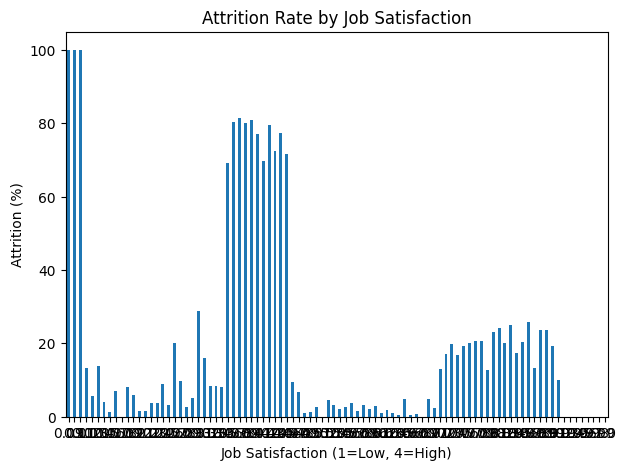

In [7]:
import matplotlib.pyplot as plt

job_sat[1].plot(kind='bar', figsize=(7,5))

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction (1=Low, 4=High)")
plt.ylabel("Attrition (%)")
plt.xticks(rotation=0)
plt.show()

In [8]:
overtime = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()*100

print(overtime)

KeyError: 'OverTime'

In [12]:
salary_counts = df.groupby('left')['salary'].value_counts().unstack()

print(salary_counts)

salary  high   low  medium
left                      
0       1155  5144    5129
1         82  2172    1317


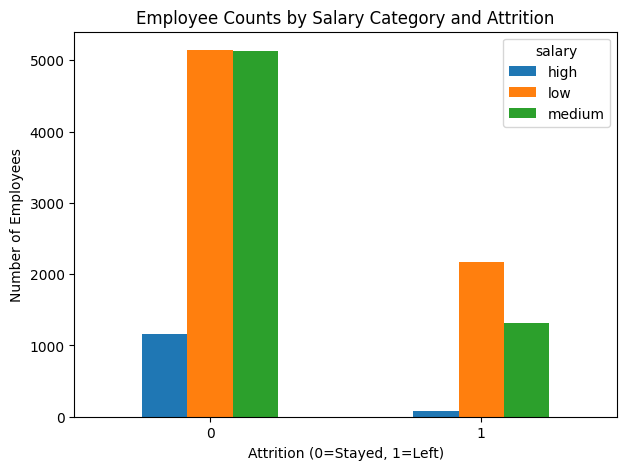

In [14]:
salary_counts.plot(kind='bar', figsize=(7,5))

plt.title("Employee Counts by Salary Category and Attrition")
plt.xlabel("Attrition (0=Stayed, 1=Left)")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

In [16]:
corr = df.select_dtypes(include='number').corr()

# Let's try correlating with 'average_montly_hours' instead
print(corr['average_montly_hours'].sort_values(ascending=False))

average_montly_hours     1.000000
number_project           0.417211
last_evaluation          0.339742
time_spend_company       0.127755
left                     0.071287
promotion_last_5years   -0.003544
Work_accident           -0.010143
satisfaction_level      -0.020048
Name: average_montly_hours, dtype: float64


In [18]:
attrition = df['left'].value_counts(normalize=True)*100

print(attrition)

left
0    76.191746
1    23.808254
Name: proportion, dtype: float64


In [19]:
# Average number of projects by employee status
project_attrition = df.groupby('left')['number_project'].mean()

print(project_attrition)

left
0    3.786664
1    3.855503
Name: number_project, dtype: float64


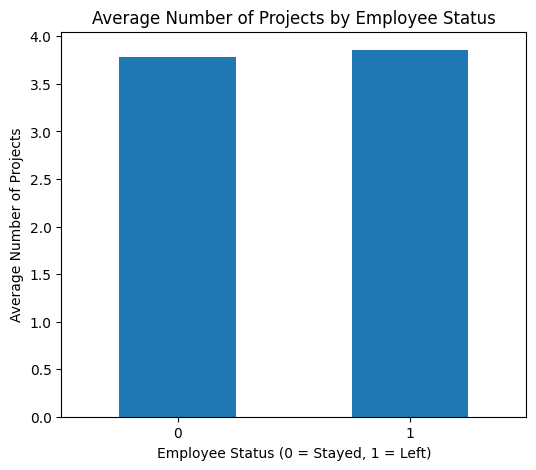

In [20]:
import matplotlib.pyplot as plt

project_attrition.plot(kind='bar', figsize=(6,5))

plt.title("Average Number of Projects by Employee Status")
plt.xlabel("Employee Status (0 = Stayed, 1 = Left)")
plt.ylabel("Average Number of Projects")
plt.xticks(rotation=0)

plt.show()

In [21]:
attrition_rate = df.groupby('number_project')['left'].mean() * 100

print(attrition_rate)

number_project
2     65.619765
3      1.775586
4      9.369989
5     22.165882
6     55.792164
7    100.000000
Name: left, dtype: float64


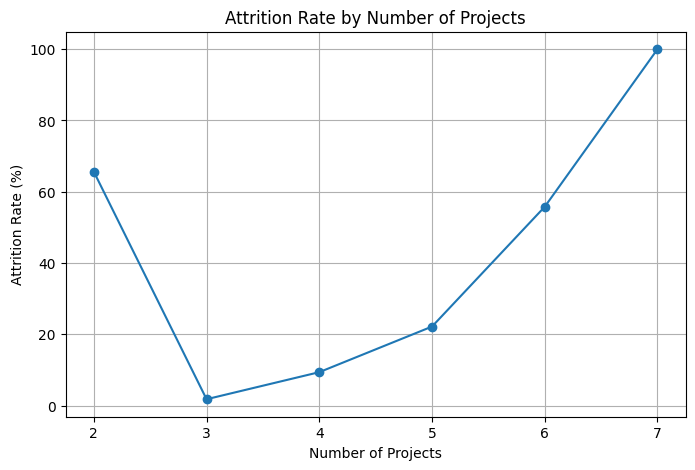

In [22]:
attrition_rate.plot(kind='line', marker='o', figsize=(8,5))

plt.title("Attrition Rate by Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)

plt.show()

The analysis suggests that employees assigned a moderate number of projects (around 3–4) are more likely to remain with the company. Attrition increases significantly among employees handling 6 or more projects, indicating that excessive workload may contribute to employees leaving. Therefore, employees with more projects are generally more likely to leave, especially when the workload becomes too high. Organizations can reduce attrition by balancing project assignments and avoiding employee overload.